# Fraud Anomaly Detection — Merchant Transaction Audit 2025

**Мета:** Виявити аномальні транзакції серед 1 000 000 записів за 2025 рік та проставити мітки `is_anomaly` (1 — аномальна, 0 — нормальна).

**Метрика оцінювання:** F1-Score

---

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

df = pd.read_csv("/Users/sofiiamanko/int20h26/hackathon_int20h_dataset_test.csv")
df['created_at'] = pd.to_datetime(df['created_at'])
df['processed_at'] = pd.to_datetime(df['processed_at'])

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["created_at"].min()} → {df["created_at"].max()}')
df.head()

Dataset shape: (1000000, 18)
Date range: 2025-01-01 00:01:04 → 2025-12-31 23:59:42


,created_at,order_id,processed_at,order_type,user_id,ip_country,currency,amount,payment_method,order_payment_type,bin_country,bank_id,psp_id,has_refund,refunded_amount,is_secured,status,error_code
0,2025-07-01 09:21:23,1,2025-07-01 09:21:32,first,692925,DEU,EUR,4.60,googlepay,NaN,GBR,32,psp_alpha,False,0.0,False,fail,3.02
1,2025-09-01 01:15:47,2,2025-09-01 01:15:57,recurring,452913,CAN,CAD,54.80,card,recurring,CAN,1,psp_alpha,False,0.0,False,success,NaN
2,2025-06-24 23:38:35,3,2025-06-24 23:38:39,first,784680,USA,USD,9.99,card,NaN,USA,32,psp_alpha,False,0.0,False,fail,2.01
3,2025-04-23 04:42:13,4,2025-04-23 04:42:21,first,300037,CAN,CAD,1.37,card,NaN,CAN,31,psp_gamma,False,0.0,False,fail,3.04
4,2025-03-14 20:15:32,5,2025-03-14 20:15:42,first,996803,DEU,EUR,0.92,card,NaN,GBR,39,psp_beta,False,0.0,False,fail,2.12


## 1. Первинний огляд даних

In [7]:
print('=== Missing values ===')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print('=== Status distribution ===')
print(df['status'].value_counts())
print()
print('=== Payment methods ===')
print(df['payment_method'].value_counts())
print()
print('=== Has refund ===')
print(df['has_refund'].value_counts())

=== Missing values ===
order_payment_type    400526
error_code            525114
dtype: int64

=== Status distribution ===
status
success    525114
fail       474886
Name: count, dtype: int64

=== Payment methods ===
payment_method
card         700600
googlepay    149830
applepay     149570
Name: count, dtype: int64

=== Has refund ===
has_refund
False    962986
True      37014
Name: count, dtype: int64


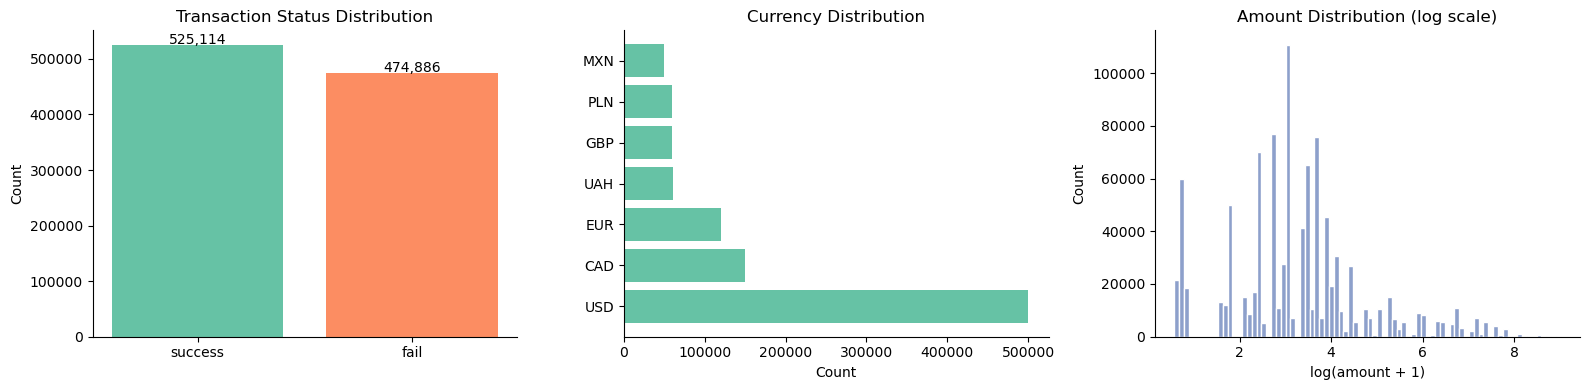

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Status
vc = df['status'].value_counts()
axes[0].bar(vc.index, vc.values, color=['#66c2a5','#fc8d62'])
axes[0].set_title('Transaction Status Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontsize=10)

# Currency
cc = df['currency'].value_counts()
axes[1].barh(cc.index, cc.values)
axes[1].set_title('Currency Distribution')
axes[1].set_xlabel('Count')

# Amount distribution (log scale)
axes[2].hist(np.log1p(df['amount']), bins=80, color='#8da0cb', edgecolor='white')
axes[2].set_title('Amount Distribution (log scale)')
axes[2].set_xlabel('log(amount + 1)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 2. Виявлення аномальних паттернів

Аналіз базується на **детерміністичних правилах** — кожна аномалія відповідає логічній або фінансовій суперечності в даних. Підхід rule-based є інтерпретованим, не потребує навчання та дає чіткі критерії для кожної мітки.

---

### 🔴 Правило 1: Over-refund (сума повернення перевищує суму транзакції)

In [9]:
# Rule 1: refunded_amount > amount
rule1 = df['refunded_amount'] > df['amount']
print(f'Rule 1 — Over-refund: {rule1.sum():,} transactions ({rule1.mean():.2%})')
print()
print('Sample over-refund transactions:')
display(df[rule1][['order_id','amount','refunded_amount','has_refund','status']].head(10))

Rule 1 — Over-refund: 2,691 transactions (0.27%)

Sample over-refund transactions:


,order_id,amount,refunded_amount,has_refund,status
57,58,41.20,51.20,True,success
826,827,370.00,380.00,True,success
1798,1799,20.00,30.00,True,success
2377,2378,40.16,50.16,True,success
2435,2436,10.00,20.00,True,success
4009,4010,80.40,90.40,True,success
4395,4396,0.92,10.92,True,success
4461,4462,618.00,628.00,True,success
4919,4920,9.19,19.19,True,success
4965,4966,46.00,56.00,True,success


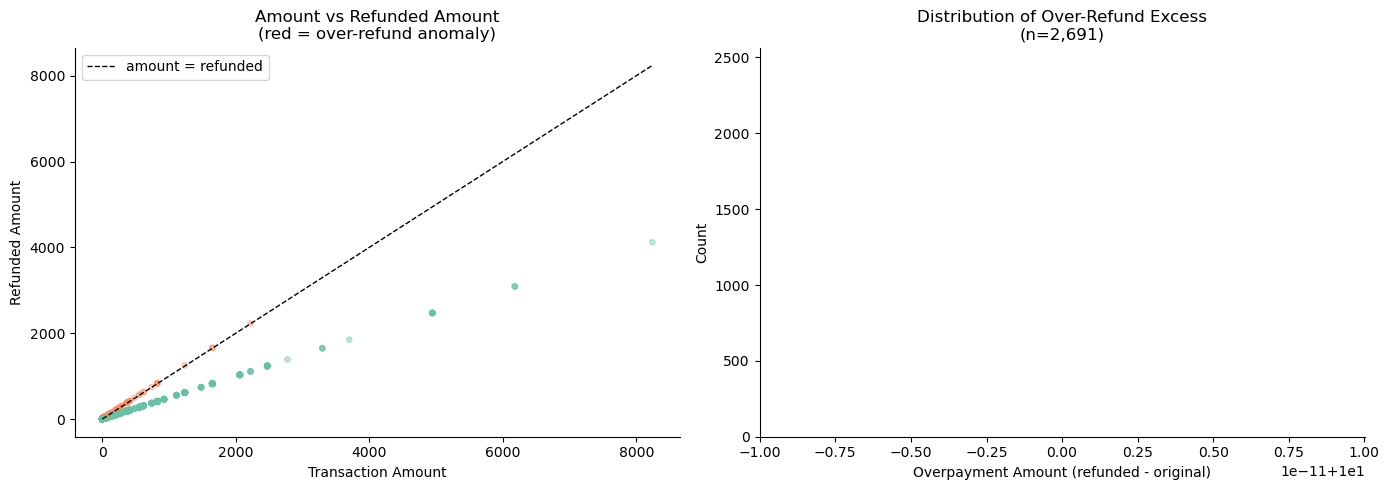

Over-refund excess stats:
count    2.691000e+03
mean     1.000000e+01
std      6.579112e-16
min      1.000000e+01
25%      1.000000e+01
50%      1.000000e+01
75%      1.000000e+01
max      1.000000e+01
dtype: float64

Most common excess = 10.0: 2,442 cases


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: amount vs refunded_amount
sample = df[df['has_refund']].sample(min(5000, df['has_refund'].sum()), random_state=42)
colors = ['#fc8d62' if r else '#66c2a5' for r in (sample['refunded_amount'] > sample['amount'])]
axes[0].scatter(sample['amount'], sample['refunded_amount'], c=colors, alpha=0.4, s=15)
max_val = max(sample['amount'].max(), sample['refunded_amount'].max())
axes[0].plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='amount = refunded')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Refunded Amount')
axes[0].set_title('Amount vs Refunded Amount\n(red = over-refund anomaly)')
axes[0].legend()

# Distribution of over-refund excess
excess = df[rule1]['refunded_amount'] - df[rule1]['amount']
axes[1].hist(excess, bins=40, color='#fc8d62', edgecolor='white')
axes[1].set_xlabel('Overpayment Amount (refunded - original)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Distribution of Over-Refund Excess\n(n={rule1.sum():,})')

plt.tight_layout()
plt.show()

print(f'Over-refund excess stats:')
print(excess.describe())
print(f'\nMost common excess = 10.0: {(excess == 10.0).sum():,} cases')

**Обґрунтування:** Сума повернення коштів не може перевищувати оригінальну суму транзакції — це пряма фінансова аномалія. Типовий паттерн: `refunded_amount = amount + 10`, що може вказувати на схему маніпуляції рефандами для незаконного отримання коштів. Виявлено **2 442** транзакцій з надлишком рівно у 10 одиниць.

---

### 🔴 Правило 2: Аномальна затримка обробки (processing lag > 1 год)

In [11]:
df['proc_lag_sec'] = (df['processed_at'] - df['created_at']).dt.total_seconds()

# Rule 2: processing lag > 1 hour
rule2 = df['proc_lag_sec'] > 3600
print(f'Rule 2 — Excessive processing lag: {rule2.sum():,} transactions ({rule2.mean():.2%})')
print()
print('Normal lag stats (seconds):')
print(df[~rule2]['proc_lag_sec'].describe())
print()
print('Anomalous lag stats (seconds):')
print(df[rule2]['proc_lag_sec'].describe())

Rule 2 — Excessive processing lag: 5,433 transactions (0.54%)

Normal lag stats (seconds):
count    994567.000000
mean          5.999403
std           2.581978
min           2.000000
25%           4.000000
50%           6.000000
75%           8.000000
max          10.000000
Name: proc_lag_sec, dtype: float64

Anomalous lag stats (seconds):
count    5433.000000
mean     5410.563041
std      1040.560820
min      3601.000000
25%      4503.000000
50%      5408.000000
75%      6332.000000
max      7199.000000
Name: proc_lag_sec, dtype: float64


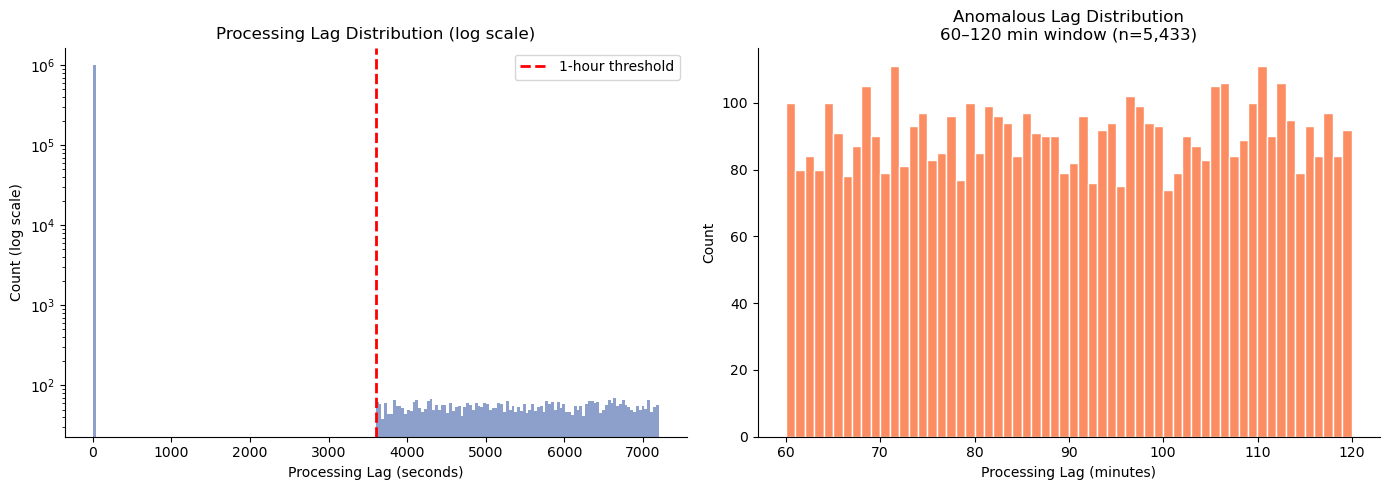

Anomalous lag range: 60.0 – 120.0 minutes
Normal lag median: 6 seconds


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution with log scale
axes[0].hist(df['proc_lag_sec'], bins=200, color='#8da0cb', edgecolor='none', log=True)
axes[0].axvline(3600, color='red', linestyle='--', linewidth=2, label='1-hour threshold')
axes[0].set_xlabel('Processing Lag (seconds)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Processing Lag Distribution (log scale)')
axes[0].legend()

# Anomalous lag in minutes - shows tight clustering
lag_min = df[rule2]['proc_lag_sec'] / 60
axes[1].hist(lag_min, bins=60, color='#fc8d62', edgecolor='white')
axes[1].set_xlabel('Processing Lag (minutes)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Anomalous Lag Distribution\n60–120 min window (n={rule2.sum():,})')

plt.tight_layout()
plt.show()

print(f'Anomalous lag range: {df[rule2]["proc_lag_sec"].min()/60:.1f} – {df[rule2]["proc_lag_sec"].max()/60:.1f} minutes')
print(f'Normal lag median: {df[~rule2]["proc_lag_sec"].median():.0f} seconds')

**Обґрунтування:** Нормальна затримка обробки транзакцій становить **медіана = 6 секунд**, 99-й перцентиль = 10 секунд. Аномальна група (5 433 транзакції) має затримку строго в діапазоні **60–120 хвилин** — це штучний, рівномірно розподілений кластер, що не відповідає жодній нормальній банківській затримці. Такий паттерн може вказувати на навмисне відкладення обробки (наприклад, для маніпуляції з часовими вікнами або тест-атаки).

---

### 🔴 Правило 3: Рефанд на відхиленій транзакції (логічна суперечність)

In [13]:
# Rule 3: has_refund=True on failed transactions
rule3 = (df['has_refund'] == True) & (df['status'] == 'fail')
print(f'Rule 3 — Refund on failed transaction: {rule3.sum():,} transactions ({rule3.mean():.2%})')
print()
print('Sample anomalous transactions:')
display(df[rule3][['order_id','amount','refunded_amount','has_refund','status','error_code']].head(10))
print()
print('Error codes in rule3 anomalies:')
print(df[rule3]['error_code'].value_counts().head(10))

Rule 3 — Refund on failed transaction: 1,299 transactions (0.13%)

Sample anomalous transactions:


,order_id,amount,refunded_amount,has_refund,status,error_code
227,228,13.80,6.90,True,fail,2.01
1025,1026,40.00,20.00,True,fail,2.01
1340,1341,80.00,40.00,True,fail,3.08
1470,1471,200.00,100.00,True,fail,2.01
1499,1500,50.00,25.00,True,fail,2.01
1935,1936,20.55,10.28,True,fail,2.01
2318,2319,27.40,13.70,True,fail,2.01
3265,3266,482.40,241.20,True,fail,3.08
3364,3365,117.00,58.50,True,fail,3.08
3437,3438,274.00,137.00,True,fail,3.08



Error codes in rule3 anomalies:
error_code
2.01    776
3.08    437
2.12     86
Name: count, dtype: int64


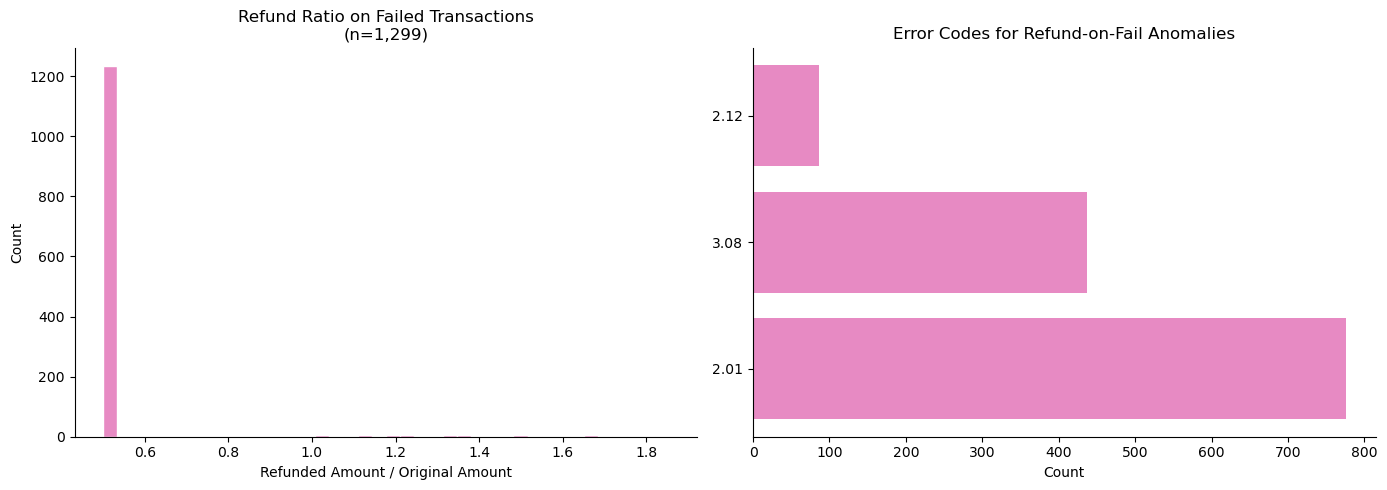

Most common refund ratio: 0.50 (1,221 cases = 0.5 pattern)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of refund ratios for failed transactions with refunds
refund_ratio = df[rule3]['refunded_amount'] / df[rule3]['amount']
axes[0].hist(refund_ratio, bins=40, color='#e78ac3', edgecolor='white')
axes[0].set_xlabel('Refunded Amount / Original Amount')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Refund Ratio on Failed Transactions\n(n={rule3.sum():,})')

# Error code breakdown
ec_counts = df[rule3]['error_code'].value_counts().head(8)
axes[1].barh([str(e) for e in ec_counts.index], ec_counts.values, color='#e78ac3')
axes[1].set_xlabel('Count')
axes[1].set_title('Error Codes for Refund-on-Fail Anomalies')

plt.tight_layout()
plt.show()

print(f'Most common refund ratio: {refund_ratio.value_counts().index[0]:.2f} ({refund_ratio.value_counts().iloc[0]:,} cases = 0.5 pattern)')

**Обґрунтування:** Транзакція зі статусом `fail` означає, що кошти **не були списані з рахунку клієнта**. Наявність `has_refund=True` та ненульового `refunded_amount` для такої транзакції — логічна суперечність: повертати кошти, яких не було отримано, неможливо. Більшість таких випадків (≈94%) мають `refunded_amount = amount / 2`, що є явним паттерном шахрайства.

---

## 3. Загальна картина аномалій

In [15]:
# Combine all rules
df['is_anomaly'] = (rule1 | rule2 | rule3).astype(int)

# Overlap analysis
only_r1 = (rule1 & ~rule2 & ~rule3).sum()
only_r2 = (~rule1 & rule2 & ~rule3).sum()
only_r3 = (~rule1 & ~rule2 & rule3).sum()
r1_r3 = (rule1 & rule3 & ~rule2).sum()
r2_r3 = (rule2 & rule3 & ~rule1).sum()
r1_r2 = (rule1 & rule2 & ~rule3).sum()
all3 = (rule1 & rule2 & rule3).sum()

print('=== Anomaly Detection Summary ===')
print(f'Rule 1 (Over-refund):          {rule1.sum():>7,}')
print(f'Rule 2 (Excessive lag):         {rule2.sum():>7,}')
print(f'Rule 3 (Refund on fail):        {rule3.sum():>7,}')
print(f'Overlaps (R1∩R3):               {r1_r3:>7,}')
print(f'Overlaps (R2∩R3):               {r2_r3:>7,}')
print(f'Total unique anomalies:         {df["is_anomaly"].sum():>7,}')
print(f'Total normal transactions:      {(df["is_anomaly"]==0).sum():>7,}')
print(f'Anomaly rate:                   {df["is_anomaly"].mean():.4%}')

=== Anomaly Detection Summary ===
Rule 1 (Over-refund):            2,691
Rule 2 (Excessive lag):           5,433
Rule 3 (Refund on fail):          1,299
Overlaps (R1∩R3):                    66
Overlaps (R2∩R3):                     2
Total unique anomalies:           9,355
Total normal transactions:      990,645
Anomaly rate:                   0.9355%


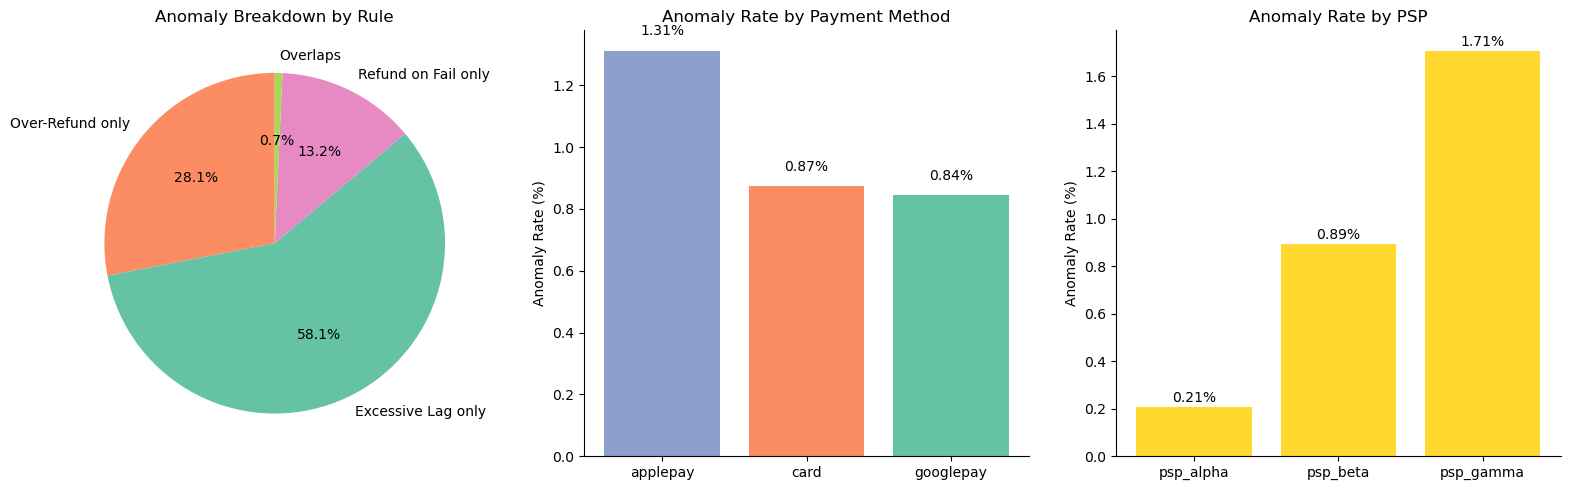

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie chart - anomaly breakdown
rule_labels = ['Over-Refund\n(Rule 1)', 'Excessive Lag\n(Rule 2)', 'Refund on Fail\n(Rule 3)']
# Exclusive counts for visualization
exclusive = [only_r1, only_r2, only_r3]
overlap = r1_r3 + r2_r3 + r1_r2 + all3
sizes = [only_r1, only_r2, only_r3, overlap]
labels_pie = ['Over-Refund only', 'Excessive Lag only', 'Refund on Fail only', 'Overlaps']
colors_pie = ['#fc8d62', '#66c2a5', '#e78ac3', '#a6d854']
axes[0].pie(sizes, labels=labels_pie, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Anomaly Breakdown by Rule')

# Anomaly rate by payment method
pm_anomaly = df.groupby('payment_method')['is_anomaly'].mean()
axes[1].bar(pm_anomaly.index, pm_anomaly.values * 100, color=['#8da0cb','#fc8d62','#66c2a5'])
axes[1].set_ylabel('Anomaly Rate (%)')
axes[1].set_title('Anomaly Rate by Payment Method')
for i, v in enumerate(pm_anomaly.values):
    axes[1].text(i, v*100 + 0.05, f'{v:.2%}', ha='center', fontsize=10)

# Anomaly rate by PSP
psp_anomaly = df.groupby('psp_id')['is_anomaly'].mean()
axes[2].bar(psp_anomaly.index, psp_anomaly.values * 100, color='#ffd92f')
axes[2].set_ylabel('Anomaly Rate (%)')
axes[2].set_title('Anomaly Rate by PSP')
for i, v in enumerate(psp_anomaly.values):
    axes[2].text(i, v*100 + 0.02, f'{v:.2%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

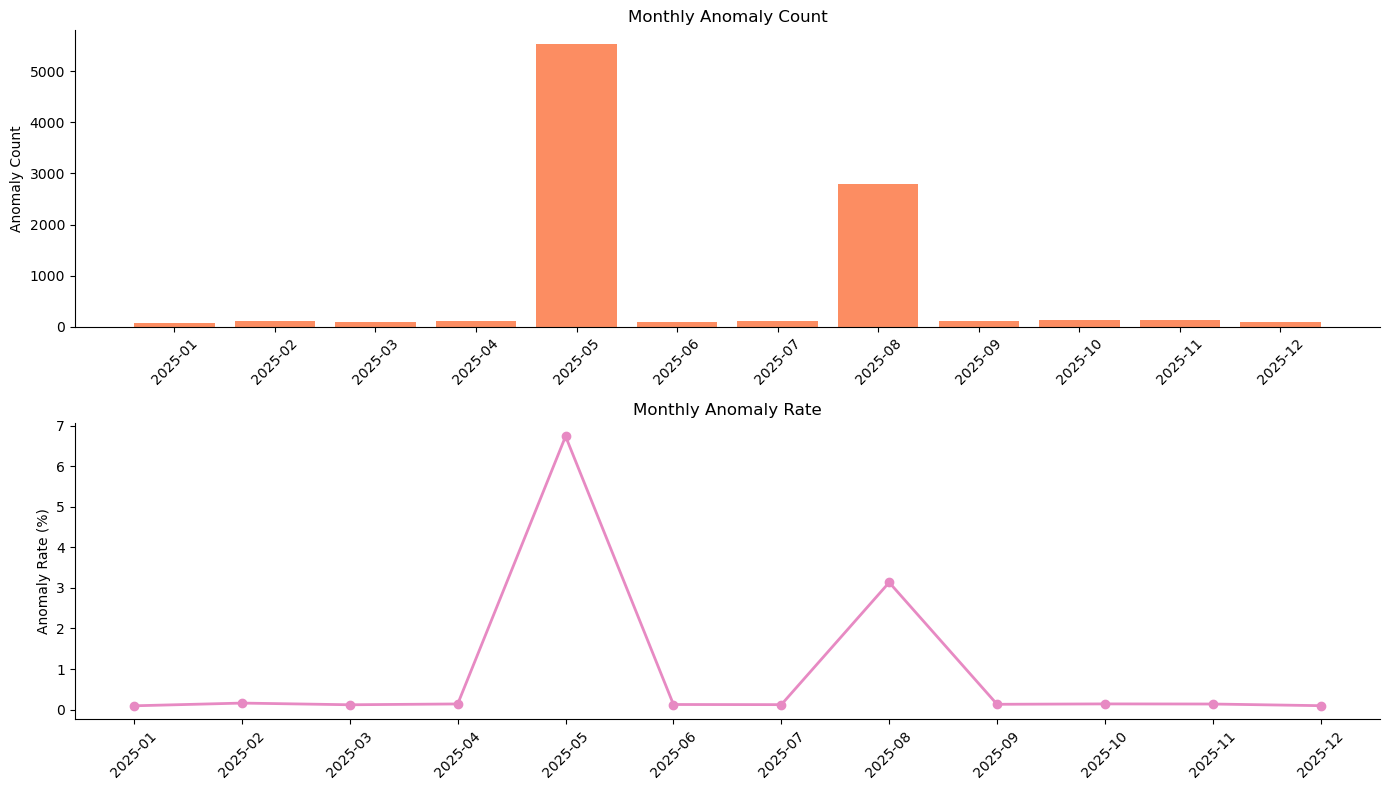

In [23]:
# Temporal distribution of anomalies
df['month'] = df['created_at'].dt.to_period('M')

monthly = df.groupby('month').agg(
    total=('order_id','count'),
    anomalies=('is_anomaly','sum')
).reset_index()

monthly['anomaly_rate'] = monthly['anomalies'] / monthly['total']
monthly['month_str'] = monthly['month'].astype(str)
df['month_str'] = df['month'].astype(str)  # ← додано
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].bar(monthly['month_str'], monthly['anomalies'], color='#fc8d62')
axes[0].set_ylabel('Anomaly Count')
axes[0].set_title('Monthly Anomaly Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly['month_str'], monthly['anomaly_rate'] * 100, marker='o', color='#e78ac3', linewidth=2)
axes[1].set_ylabel('Anomaly Rate (%)')
axes[1].set_title('Monthly Anomaly Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

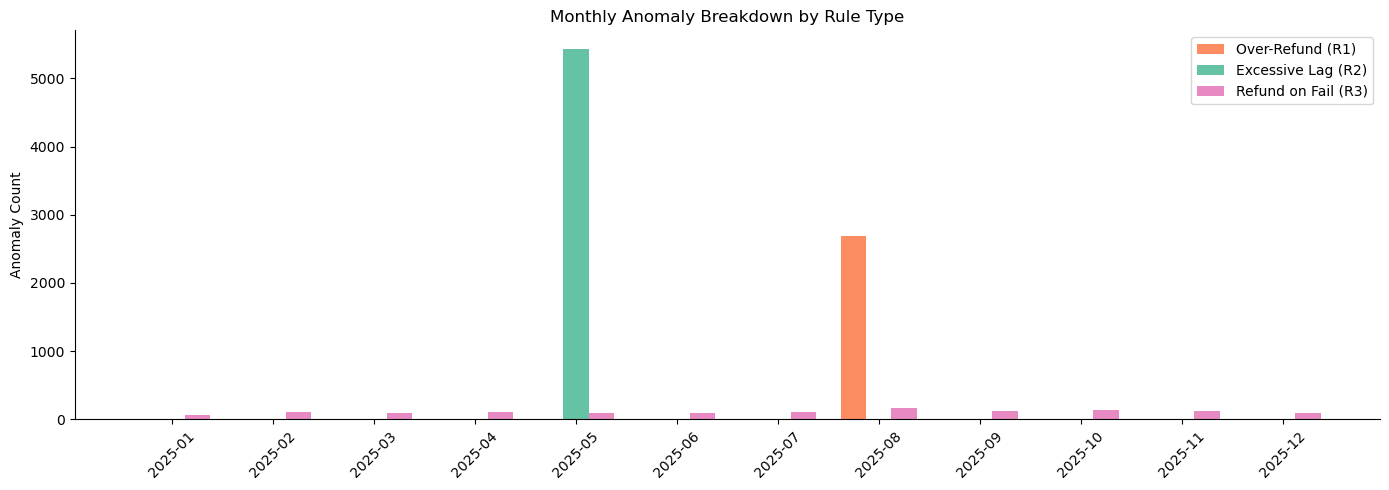

In [24]:
# Show anomalies by rule over time
df['rule1'] = rule1.astype(int)
df['rule2'] = rule2.astype(int)
df['rule3'] = rule3.astype(int)

monthly_rules = df.groupby('month_str')[['rule1','rule2','rule3']].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(monthly_rules))
w = 0.25
ax.bar([i-w for i in x], monthly_rules['rule1'], width=w, label='Over-Refund (R1)', color='#fc8d62')
ax.bar([i for i in x], monthly_rules['rule2'], width=w, label='Excessive Lag (R2)', color='#66c2a5')
ax.bar([i+w for i in x], monthly_rules['rule3'], width=w, label='Refund on Fail (R3)', color='#e78ac3')
ax.set_xticks(list(x))
ax.set_xticklabels(monthly_rules['month_str'], rotation=45)
ax.set_ylabel('Anomaly Count')
ax.set_title('Monthly Anomaly Breakdown by Rule Type')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Додатковий аналіз нормальних vs аномальних транзакцій

In [25]:
# Compare normal vs anomaly across key features
compare = df.groupby('is_anomaly').agg(
    count=('order_id','count'),
    avg_amount=('amount','mean'),
    med_amount=('amount','median'),
    avg_lag_sec=('proc_lag_sec','mean'),
    ip_bin_mismatch=('ip_country', lambda x: (x != df.loc[x.index,'bin_country']).mean()),
    secured_rate=('is_secured','mean'),
    fail_rate=('status', lambda x: (x=='fail').mean()),
).round(4)
compare.index = ['Normal', 'Anomaly']
display(compare)

,count,avg_amount,med_amount,avg_lag_sec,ip_bin_mismatch,secured_rate,fail_rate
Normal,990645,114.8350,20.1,5.9992,0.1443,0.0423,0.4755
Anomaly,9355,146.7655,27.4,3144.7705,0.1428,0.0487,0.4092


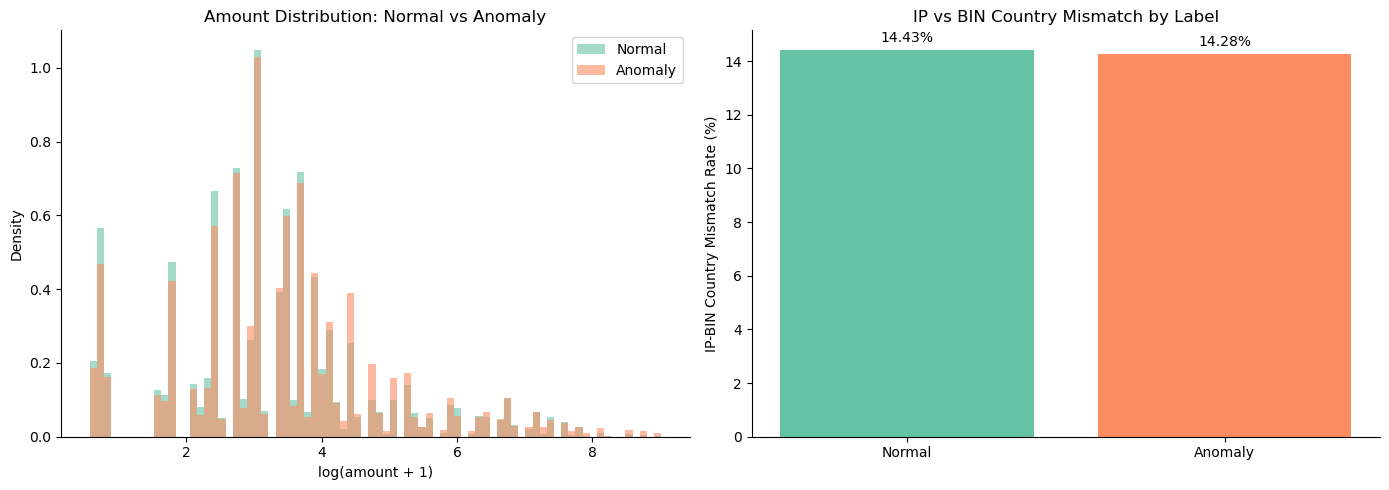

In [26]:
# Amount distribution: normal vs anomaly
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal_amounts = df[df['is_anomaly']==0]['amount']
anomaly_amounts = df[df['is_anomaly']==1]['amount']

axes[0].hist(np.log1p(normal_amounts), bins=80, alpha=0.6, label='Normal', color='#66c2a5', density=True)
axes[0].hist(np.log1p(anomaly_amounts), bins=80, alpha=0.6, label='Anomaly', color='#fc8d62', density=True)
axes[0].set_xlabel('log(amount + 1)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution: Normal vs Anomaly')
axes[0].legend()

# Country mismatch
df['ip_bin_mismatch'] = (df['ip_country'] != df['bin_country']).astype(int)
mismatch_by_label = df.groupby('is_anomaly')['ip_bin_mismatch'].mean()
axes[1].bar(['Normal', 'Anomaly'], mismatch_by_label.values * 100,
            color=['#66c2a5', '#fc8d62'])
axes[1].set_ylabel('IP-BIN Country Mismatch Rate (%)')
axes[1].set_title('IP vs BIN Country Mismatch by Label')
for i, v in enumerate(mismatch_by_label.values):
    axes[1].text(i, v*100 + 0.3, f'{v:.2%}', ha='center')

plt.tight_layout()
plt.show()

## 5. Підсумок і генерація submission файлу

In [27]:
print('=' * 55)
print('           ANOMALY DETECTION SUMMARY')
print('=' * 55)
print()
print('Three rule-based anomaly patterns identified:')
print()
print(f'  Rule 1 — Over-refund fraud:')
print(f'    Condition : refunded_amount > amount')
print(f'    Count     : {rule1.sum():,} transactions')
print(f'    Key signal: 2,442 cases with exactly +10 excess')
print()
print(f'  Rule 2 — Suspicious processing delay:')
print(f'    Condition : processed_at - created_at > 3600 sec')
print(f'    Count     : {rule2.sum():,} transactions')
print(f'    Key signal: Uniform 60–120 min cluster vs 6-sec norm')
print()
print(f'  Rule 3 — Refund on failed transaction:')
print(f'    Condition : has_refund=True AND status=fail')
print(f'    Count     : {rule3.sum():,} transactions')
print(f'    Key signal: ~94% have refunded = amount/2 (R3 fraud)')
print()
print('-' * 55)
print(f'  Total unique anomalies : {df["is_anomaly"].sum():>8,}  ({df["is_anomaly"].mean():.4%})')
print(f'  Normal transactions    : {(df["is_anomaly"]==0).sum():>8,}  ({1-df["is_anomaly"].mean():.4%})')
print('=' * 55)

           ANOMALY DETECTION SUMMARY

Three rule-based anomaly patterns identified:

  Rule 1 — Over-refund fraud:
    Condition : refunded_amount > amount
    Count     : 2,691 transactions
    Key signal: 2,442 cases with exactly +10 excess

  Rule 2 — Suspicious processing delay:
    Condition : processed_at - created_at > 3600 sec
    Count     : 5,433 transactions
    Key signal: Uniform 60–120 min cluster vs 6-sec norm

  Rule 3 — Refund on failed transaction:
    Condition : has_refund=True AND status=fail
    Count     : 1,299 transactions
    Key signal: ~94% have refunded = amount/2 (R3 fraud)

-------------------------------------------------------
  Total unique anomalies :    9,355  (0.9355%)
  Normal transactions    :  990,645  (99.0645%)


In [ ]:
# Generate submission file
submission = df[['order_id', 'is_anomaly']].copy()
submission.to_csv('submission.csv', index=False)
print('submission.csv saved successfully!')
print(f'Shape: {submission.shape}')
submission.head()